In [74]:
data_dir = '/home/mjehangir/telomere-sv-analysis/data/aysa_SVs/'

In [61]:
setwd(data_dir)

In [35]:
library(circlize)
library(dplyr)
library(tidyr)
library(fuzzyjoin) 
library(dplyr)
library(ggplot2)


In [62]:
# Load the data
library(dplyr)
#data <- read.delim("/scratch/mjehangir/Glioma_project/severus/severus_out/shared_svs_summary.tsv", header = TRUE, sep = "\t")
#data <- read.delim("summarized_svs.tsv", header = TRUE, sep = "\t")
data <- read.delim("summarized_svs_v2.tsv", header = TRUE, sep = "\t")

data2 <- read.delim("/home/mjehangir/chm13_chrs_arms/chromosome_p_q_sorted_arms.tsv", header = TRUE, sep = "\t")


In [63]:
head(data)
nrow(data)
head(data2)


,cluster_id,event_id,sv_type,det_sv_type,chr_pair,n_samples,samples
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>
1,svcluster_1,chr1:3506645|chr1:3506645,sBND,loose_end,chr1_chr1,1,6414C
2,svcluster_2,chr1:11505826|chr1:11505826,sBND,loose_end,chr1_chr1,1,6414C
3,svcluster_3,chr1:12929207|chr1:12929207,sBND,loose_end,chr1_chr1,1,6414C
4,svcluster_4,chr1:14725005|chr1:14725005,sBND,loose_end,chr1_chr1,1,6414C
5,svcluster_5,chr1:14978474|chr1:14978474,sBND,loose_end,chr1_chr1,1,6414C
6,svcluster_6,chr1:16401878|chr1:16401878,sBND,loose_end,chr1_chr1,1,6414C


[1] 14690

,Chromosome,Start,End,Length,p_Arm,q_Arm
,<chr>,<int>,<int>,<int>,<chr>,<lgl>
1,chr1,0,124048267,124048267,p,NA
2,chr1,124048267,248387328,124339061,q,NA
3,chr10,0,40649191,40649191,p,NA
4,chr10,40649191,134758134,94108943,q,NA
5,chr11,0,52743313,52743313,p,NA
6,chr11,52743313,135127769,82384456,q,NA


In [64]:

# Create a summary table
sv_counts <- data %>%
  group_by(sv_type) %>%
  summarise(count = n()) %>%
  arrange(desc(count)) # Sorts with the most frequent SVs at the top

# Print to console
print(sv_counts)

# A tibble: 6 × 2
  sv_type count
  <chr>   <int>
1 sBND     9227
2 BND      3644
3 DEL       980
4 INS       557
5 DUP       276
6 INV         6


In [65]:
sv_detailed_counts <- data %>%
  group_by(sv_type, det_sv_type) %>%
  summarise(count = n(), .groups = 'drop')

print(sv_detailed_counts)

# A tibble: 16 × 3
   sv_type det_sv_type          count
   <chr>   <chr>                <int>
 1 BND     BND                   1982
 2 BND     Reciprocal_tra          40
 3 BND     Templated_ins          150
 4 BND     Templated_ins_inv       28
 5 BND     complex_inv           1140
 6 BND     dup_inv_segment        102
 7 BND     foldback                50
 8 BND     inv_tra                 88
 9 BND     reciprocal_inv_del      64
10 DEL     DEL                    980
11 DUP     DUP                      2
12 DUP     tandem_duplication     274
13 INS     INS                    557
14 INV     reciprocal_inversion     6
15 sBND    loose_end             8906
16 sBND    sBND                   321


In [75]:
head(complex_paired_df)
nrow(complex_paired_df)

,cluster_id,event_id,sv_type,det_sv_type,chr_pair,n_samples,samples
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>
1,svcluster_229,chr2:232188796|chr3:442784,BND,Templated_ins,chr2_chr3,1,6414C
2,svcluster_230,chr2:232188931|chr3:379765,BND,complex_inv,chr2_chr3,1,6414C
3,svcluster_231,chr2:232189364|chr3:379333,BND,Templated_ins,chr2_chr3,1,6414C
4,svcluster_239,chr3:377522|chr3:441356,BND,complex_inv,chr3_chr3,1,6414C
5,svcluster_240,chr3:379333|chr2:232189364,BND,Templated_ins,chr3_chr2,1,6414C
6,svcluster_241,chr3:379765|chr2:232188931,BND,complex_inv,chr3_chr2,1,6414C


[1] 1622

In [68]:

# Step 1: Split the BND event_id into two distinct breakpoints
complex_long <- complex_paired_df %>%
  separate(event_id, into = c("break_A", "break_B"), sep = "\\|") %>%
  # Separate Chromosome and Position for both sides
  separate(break_A, into = c("chr_A", "pos_A"), sep = ":", convert = TRUE) %>%
  separate(break_B, into = c("chr_B", "pos_B"), sep = ":", convert = TRUE) %>%
  # Pivot to long format: each row is now one breakend (two rows per event)
  pivot_longer(
    cols = c(chr_A, pos_A, chr_B, pos_B),
    names_to = c(".value", "side"),
    names_pattern = "(chr|pos)_(.)"
  )

# Step 2: Join with arm reference (data2)
data_with_arms <- complex_long %>%
  inner_join(data2, by = c("chr" = "Chromosome")) %>%
  filter(pos >= Start & pos <= End) %>%
  # Create a clean Arm ID (e.g., chr1p, chr1q)
  mutate(arm_id = paste0(chr, p_Arm)) %>% 
  select(cluster_id, det_sv_type, samples, chr, pos, arm_id, everything())

# Step 3: View the mapped data
head(data_with_arms)

Warning message in inner_join(., data2, by = c(chr = "Chromosome")):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 23 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


cluster_id,det_sv_type,samples,chr,pos,arm_id,sv_type,chr_pair,n_samples,side,Start,End,Length,p_Arm,q_Arm
<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<int>,<chr>,<lgl>
svcluster_229,Templated_ins,6414C,chr2,232188796,chr2q,BND,chr2_chr3,1,A,93503283,242696752,149193469,q,NA
svcluster_229,Templated_ins,6414C,chr3,442784,chr3p,BND,chr2_chr3,1,B,0,94076514,94076514,p,NA
svcluster_230,complex_inv,6414C,chr2,232188931,chr2q,BND,chr2_chr3,1,A,93503283,242696752,149193469,q,NA
svcluster_230,complex_inv,6414C,chr3,379765,chr3p,BND,chr2_chr3,1,B,0,94076514,94076514,p,NA
svcluster_231,Templated_ins,6414C,chr2,232189364,chr2q,BND,chr2_chr3,1,A,93503283,242696752,149193469,q,NA
svcluster_231,Templated_ins,6414C,chr3,379333,chr3p,BND,chr2_chr3,1,B,0,94076514,94076514,p,NA


In [76]:

# 1. Pivot the data back to 'Wide' format so one row = one event
clean_complex_table <- data_with_arms %>%
  select(cluster_id, samples, det_sv_type, side, arm_id) %>%
  pivot_wider(
    names_from = side, 
    values_from = arm_id,
    names_prefix = "arm_"
  ) %>%
  # 2. Add a logic column to identify the type of connection
  mutate(
    connection_type = ifelse(arm_A == arm_B, "Intra-arm", "Inter-arm/Inter-chr")
  ) %>%
  # 3. Rename for clarity
  rename(
    Origin_Arm = arm_A,
    Target_Arm = arm_B,
    Subtype = det_sv_type,
    Sample = samples
  )

# View the result
head(clean_complex_table)
nrow(clean_complex_table)

cluster_id,Sample,Subtype,Origin_Arm,Target_Arm,connection_type
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
svcluster_229,6414C,Templated_ins,chr2q,chr3p,Inter-arm/Inter-chr
svcluster_230,6414C,complex_inv,chr2q,chr3p,Inter-arm/Inter-chr
svcluster_231,6414C,Templated_ins,chr2q,chr3p,Inter-arm/Inter-chr
svcluster_239,6414C,complex_inv,chr3p,chr3p,Intra-arm
svcluster_240,6414C,Templated_ins,chr3p,chr2q,Inter-arm/Inter-chr
svcluster_241,6414C,complex_inv,chr3p,chr2q,Inter-arm/Inter-chr


[1] 1622

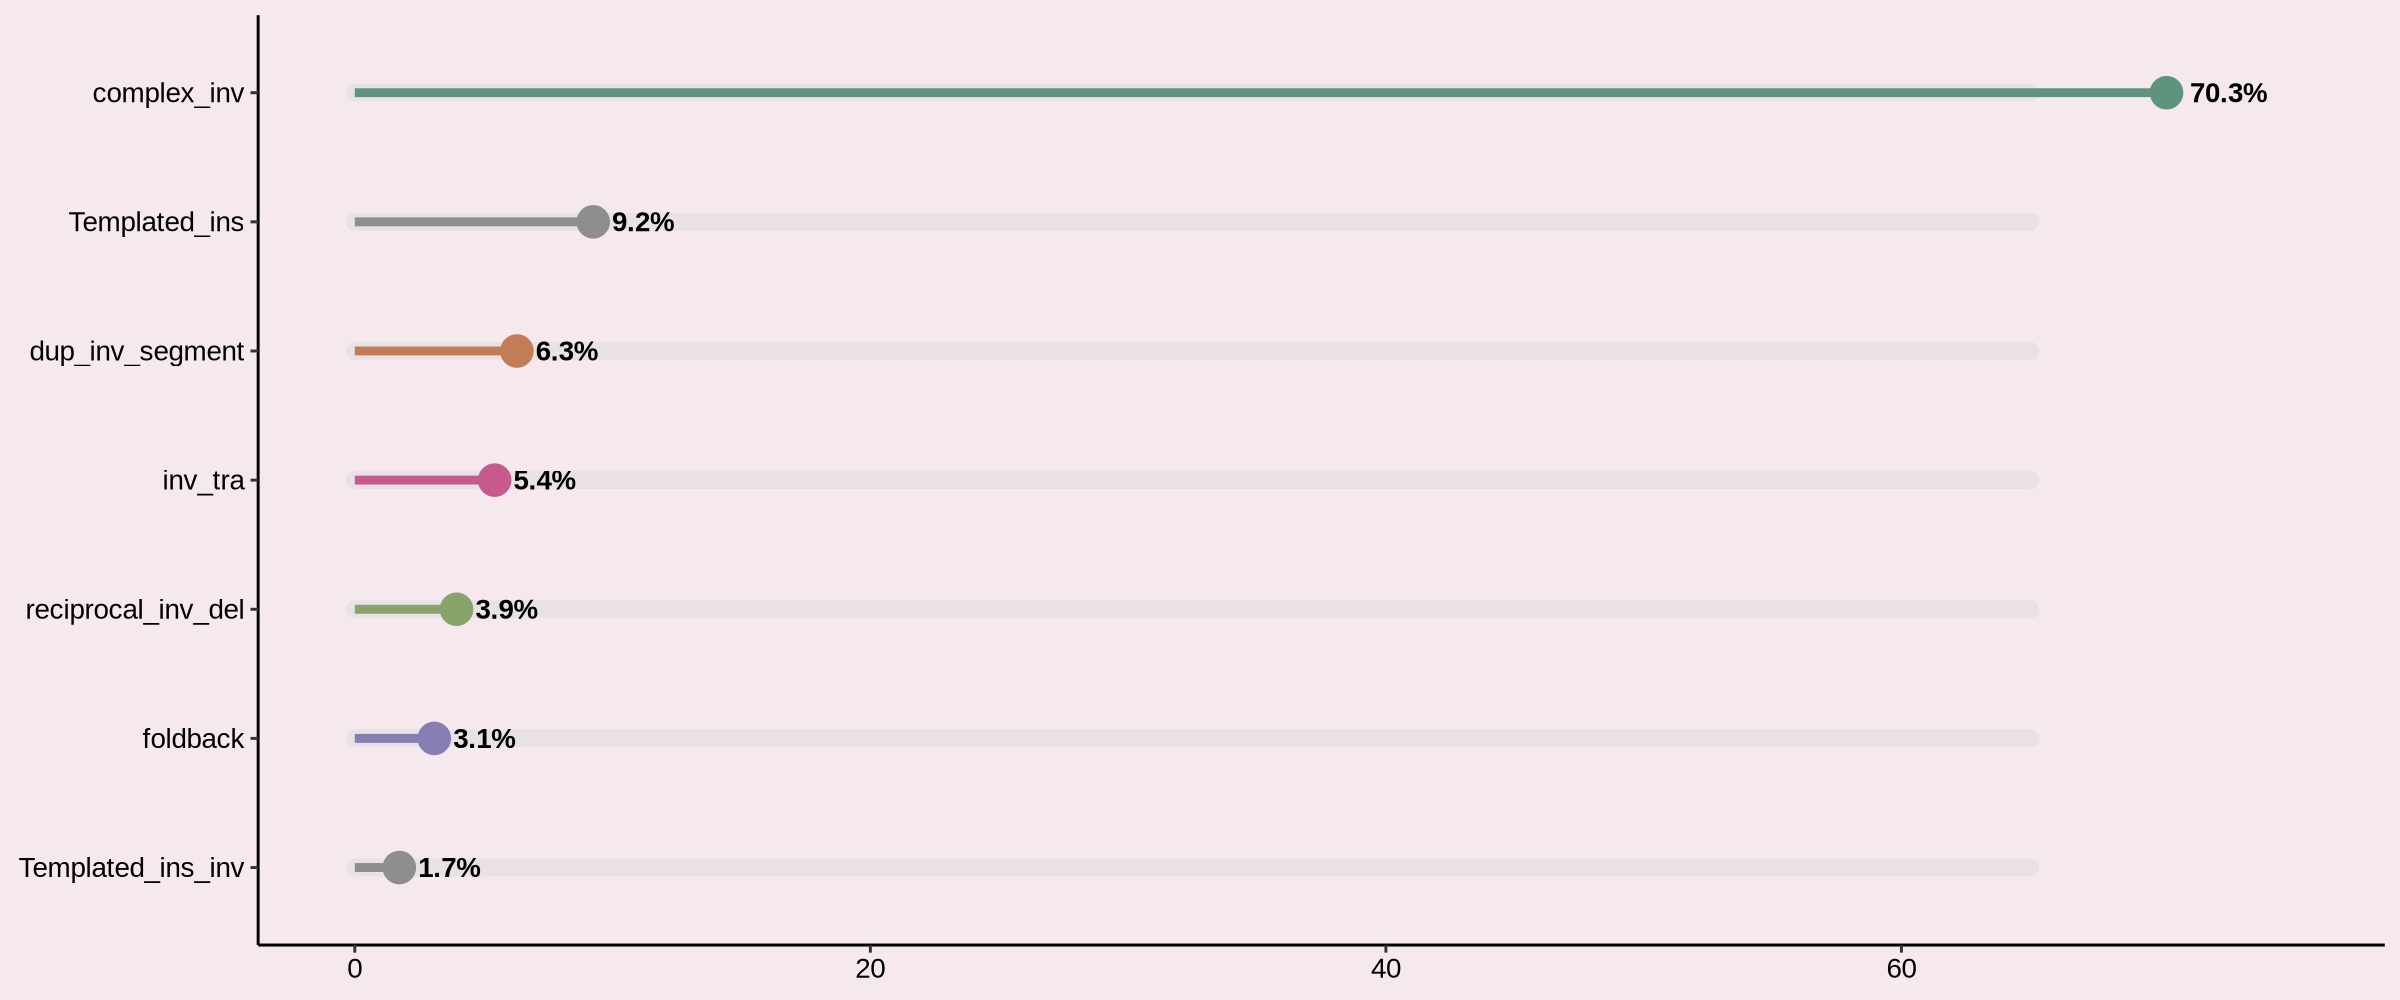

In [114]:
# 1. CLEAN AND PREPARE DATA
plot_data_total <- complex_paired_df %>%
  # Clean the names and create a matching column for colors
  mutate(
    clean_type = trimws(det_sv_type),
    # Map colors based on keywords so it is "bulletproof"
    plot_color = case_when(
      grepl("complex_inv", clean_type, ignore.case = TRUE) ~ "#5E937E", # Green
      grepl("tandem",      clean_type, ignore.case = TRUE) ~ "#D4AF60", # Gold
      grepl("dup_inv",     clean_type, ignore.case = TRUE) ~ "#C27D56", # Brown
      grepl("inv_tra",     clean_type, ignore.case = TRUE) ~ "#C65A8D", # Pink
      grepl("inv_del",     clean_type, ignore.case = TRUE) ~ "#89A46B", # Light Green
      grepl("foldback",    clean_type, ignore.case = TRUE) ~ "#877FB1", # Purple
      grepl("tra",         clean_type, ignore.case = TRUE) ~ "#A6865A", # Tan
      TRUE                                              ~ "#8E8E8E"  # Grey for others
    )
  ) %>% 
  count(clean_type, plot_color) %>%
  mutate(
    Percentage = n / sum(n),
    clean_type = reorder(clean_type, Percentage)
  )

# 2. CREATE THE PLOT
ggplot(plot_data_total, aes(x = Percentage * 100, y = clean_type)) +
  # Background "track" lines
  geom_segment(aes(x = 0, xend = 65, y = clean_type, yend = clean_type), 
               color = "#E8E1E6", size = 3, lineend = "round") +
  
  # The colored "progress" bar (Thin line)
  geom_segment(aes(x = 0, xend = Percentage * 100, y = clean_type, yend = clean_type, color = plot_color), 
               size = 1.5) +
  
  # The circular "head"
  geom_point(aes(color = plot_color), size = 5) +
  
  # Percentage labels (Ensures 59.3% is visible)
  geom_text(aes(label = sprintf("%.1f%%", Percentage * 100)), 
            hjust = -0.3, size = 3.5, color = "black", fontface = "bold") +
  
  # Apply the colors directly from the data column
  scale_color_identity() +
  
  # Formatting
  scale_x_continuous(breaks = seq(0, 60, 20)) +
  coord_cartesian(xlim = c(0, 75)) + # "Zooms out" so text isn't cut off
  theme_classic() + 
  theme(
    plot.background = element_rect(fill = "#F6E9ED", color = NA),
    panel.background = element_rect(fill = "#F6E9ED", color = NA),
    axis.line = element_line(color = "black"),
    axis.title = element_blank(),
    axis.text = element_text(color = "black", size = 10)
  )

In [102]:
clean_complex_table %>%
  # 1. Narrow down to the specific sample AND the specific arm
  filter(Sample == "6277A", Origin_Arm == "chr1q") 

cluster_id,Sample,Subtype,Origin_Arm,Target_Arm,connection_type
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
svcluster_10549,6277A,Templated_ins,chr1q,chr13q,Inter-arm/Inter-chr
svcluster_10550,6277A,Templated_ins,chr1q,chr13q,Inter-arm/Inter-chr
svcluster_10560,6277A,complex_inv,chr1q,chr13q,Inter-arm/Inter-chr
svcluster_10561,6277A,inv_tra,chr1q,chr1q,Intra-arm
svcluster_10562,6277A,complex_inv,chr1q,chr13q,Inter-arm/Inter-chr
svcluster_10565,6277A,inv_tra,chr1q,chr1q,Intra-arm


In [70]:


# 1. Summarize counts per sample, per arm, and per subtype
sample_arm_summary <- data_with_arms %>%
  group_by(samples, arm_id, Length, det_sv_type) %>%
  summarise(
    Breakend_Count = n(), 
    .groups = 'drop'
  ) %>%
  mutate(
    # Normalize by arm length (Length is in bp, convert to Mb)
    Arm_Length_Mb = Length / 1e6,
    Rate_per_Mb = Breakend_Count / Arm_Length_Mb
  ) %>%
  # Sort to bring the most significant events to the top
  arrange(desc(Rate_per_Mb))

# 2. Clean the table for final presentation
final_output <- sample_arm_summary %>%
  select(
    Sample = samples,
    Arm = arm_id,
    Subtype = det_sv_type,
    Count = Breakend_Count,
    Rate_per_Mb = Rate_per_Mb
  ) %>%
  mutate(Rate_per_Mb = round(Rate_per_Mb, 4))

# 3. View the results
print(final_output)

# A tibble: 184 × 5
   Sample Arm    Subtype       Count Rate_per_Mb
   <chr>  <chr>  <chr>         <int>       <dbl>
 1 3188   chr14q complex_inv     366       4.08 
 2 3188   chr5p  complex_inv     166       3.44 
 3 6365A  chr11q complex_inv     266       3.23 
 4 3188   chr5q  complex_inv     308       2.30 
 5 6439C  chr12q complex_inv     220       2.26 
 6 6365A  chr15q complex_inv     126       1.53 
 7 6414C  chr10q complex_inv     136       1.45 
 8 6365A  chr11q Templated_ins   102       1.24 
 9 6365A  chr15q Templated_ins   102       1.24 
10 6436B  chr10p complex_inv      40       0.984
# ℹ 174 more rows


In [101]:
final_output %>%
  # 1. Narrow down to the specific sample AND the specific arm
  filter(Sample == "6277A", Arm == "chr1q")


Sample,Arm,Subtype,Count,Rate_per_Mb
<chr>,<chr>,<chr>,<int>,<dbl>
6277A,chr1q,Templated_ins,4,0.0322
6277A,chr1q,complex_inv,4,0.0322
6277A,chr1q,inv_tra,4,0.0322


In [71]:
num_samples <- data %>% 
  summarise(n_unique = n_distinct(samples))

print(num_samples)


  n_unique
1       20


In [103]:
sample_arm_summary <- data_with_arms %>%
  group_by(samples, arm_id, Length, det_sv_type) %>%
  summarise(
    # Use n_distinct to count the unique SV IDs
    Event_Count = n_distinct(cluster_id), 
    .groups = 'drop'
  ) %>%
  mutate(
    Arm_Length_Mb = Length / 1e6,
    Rate_per_Mb = Event_Count / Arm_Length_Mb
  ) %>%
  arrange(desc(Rate_per_Mb))

# Now filter to see the difference
sample_arm_summary %>%
  filter(samples == "6277A", arm_id == "chr1q")

samples,arm_id,Length,det_sv_type,Event_Count,Arm_Length_Mb,Rate_per_Mb
<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>
6277A,chr1q,124339061,Templated_ins,4,124.3391,0.03217010
6277A,chr1q,124339061,complex_inv,4,124.3391,0.03217010
6277A,chr1q,124339061,inv_tra,2,124.3391,0.01608505


In [72]:
# Print the unique sample IDs found in your complex event analysis
unique_samples <- data_with_arms %>%
  distinct(samples) %>%
  pull(samples)

print(unique_samples)

 [1] "6414C" "6483C" "6265D" "6285B" "6266D" "3188"  "6436B" "6500D" "6478A"
[10] "6324B" "6423A" "6298B" "2436A" "6365A" "6277A" "6314E" "6605D" "6439C"
[19] "3988"  "6269C"


In [73]:
write.csv(final_output, "complex_BNDs_counts_rate.csv", row.names = FALSE)

In [ ]:
sv_type

In [106]:
# Step 1: Expand samples and filter det_sv_type
data_long <- data %>%
  separate_rows(samples, sep = ",") %>%
  filter(!det_sv_type %in% c("Templated_ins_inv", "Templated_ins", "None", "", NA))

library(stringr)

# Extract chr2 and pos2 by capturing groups
matches <- str_match(data_long$event_id, "chr[0-9XYM]+:(\\d+)\\|chr([0-9XYM]+):(\\d+)")

# The str_match result columns:
# [,1] = full match
# [,2] = pos1 (first number)
# [,3] = chr2 (second chromosome without "chr" prefix though)
# [,4] = pos2 (second number)

# So, to get chr2 with 'chr' prefix, prepend "chr" back:
data_long <- data_long %>%
  mutate(
    chr1 = str_extract(event_id, "^chr[0-9XYM]+"),
    pos1 = as.numeric(str_match(event_id, "^chr[0-9XYM]+:(\\d+)")[,2]),
    chr2 = paste0("chr", matches[,3]),
    pos2 = as.numeric(matches[,4])
  )

# Step 3: Assign colors for each det_sv_type
det_sv_colors <- RColorBrewer::brewer.pal(n = length(unique(data_long$det_sv_type)), name = "Set2")
names(det_sv_colors) <- unique(data_long$det_sv_type)

#pdf("/home/mjehangir/glioma_manuscript/circos_plot_updated.pdf", width = 8, height = 8)
# Step 4: Initialize circos plot with ideogram (for hg38)
circos.clear()
circos.par(gap.after = c(rep(1, 23), 5))  # Optional: larger gap after chrX
circos.initializeWithIdeogram(species = "hg38")  # Or customize if using another genome

# Step 5: Plot links
circos.genomicLink(
  region1 = data_long %>% select(chr1, pos1, pos1),
  region2 = data_long %>% select(chr2, pos2, pos2),
  col = det_sv_colors[data_long$det_sv_type],
  border = NA
)

# Add legend (optional)
legend("topleft", legend = names(det_sv_colors), col = det_sv_colors, lty = 1, lwd = 2, cex = 0.8)
#dev.off()

Warning message in RColorBrewer::brewer.pal(n = length(unique(data_long$det_sv_type)), :
“n too large, allowed maximum for palette Set2 is 8
Returning the palette you asked for with that many colors
”


ERROR: Error in names(det_sv_colors) <- unique(data_long$det_sv_type): 'names' attribute [14] must be the same length as the vector [8]


ERROR: Error in names(sector.data) <- colnames(.SECTOR.DATA)[-1]: 'names' attribute [6] must be the same length as the vector [0]


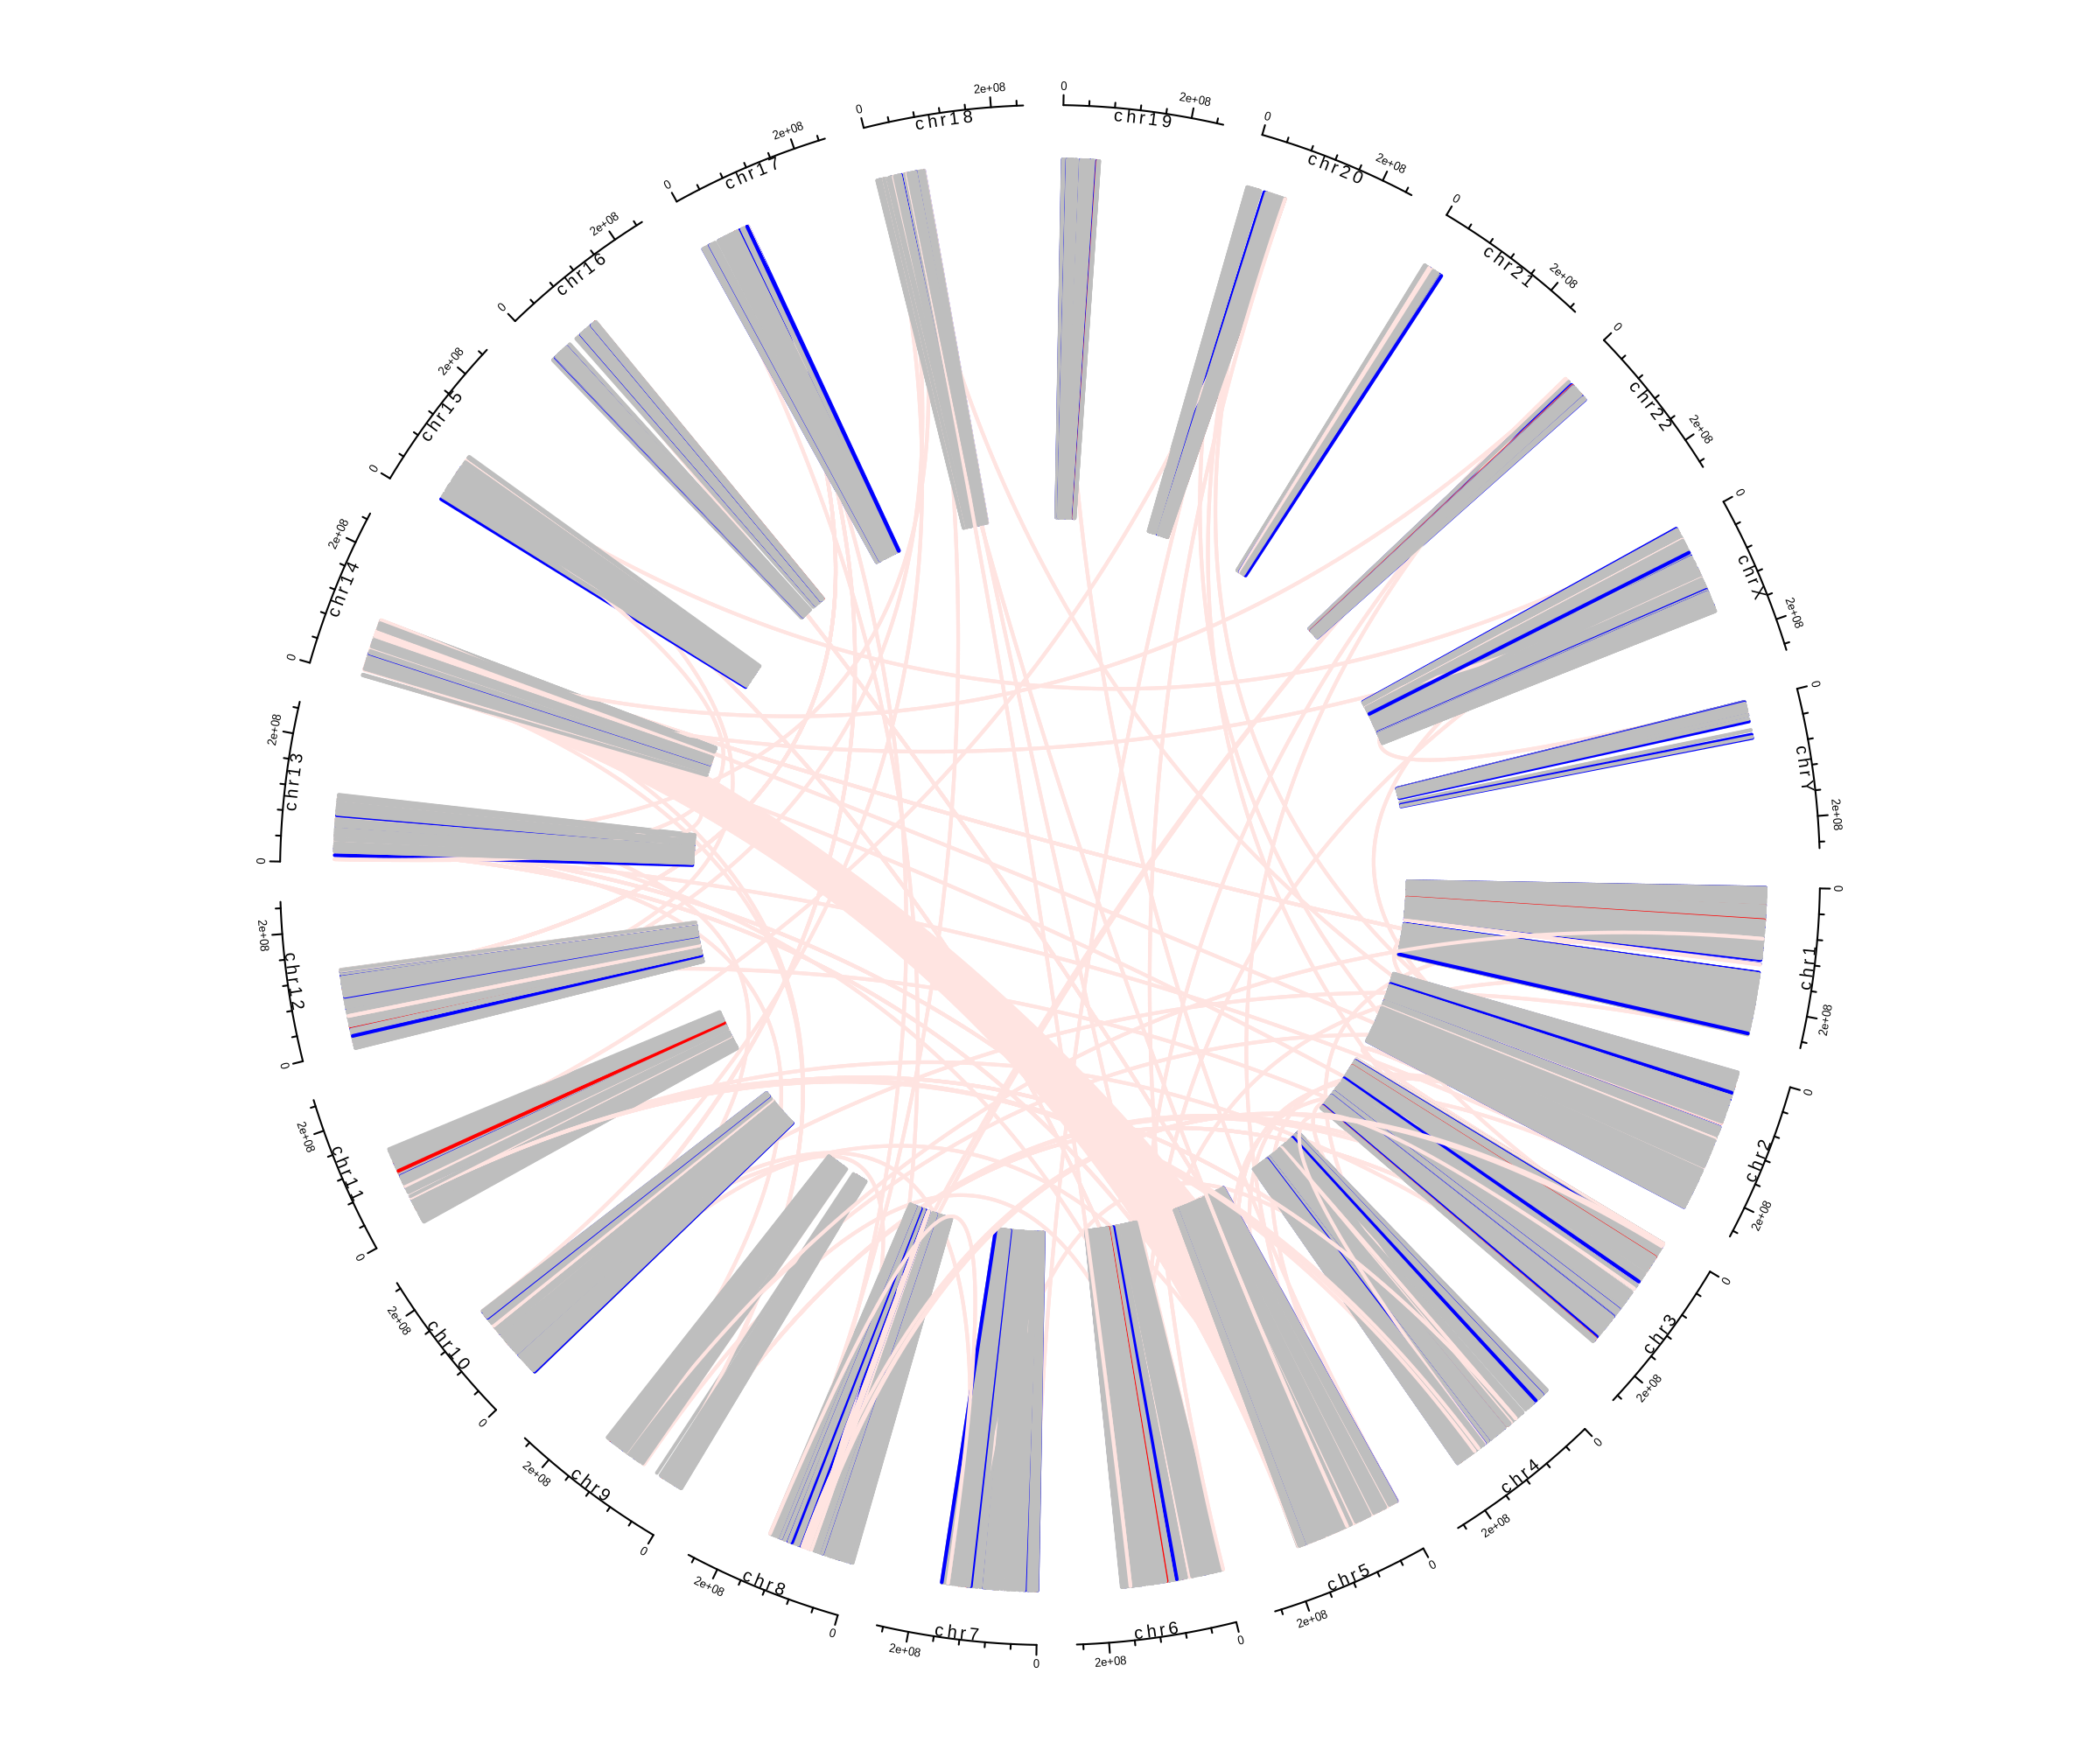

In [19]:
# ==== Parse Event Positions ====
sv_data_parsed <- data %>%
  separate(event_id, into = c("pos1", "pos2"), sep = "\\|") %>%
  separate(pos1, into = c("chr1", "start1"), sep = ":", convert = TRUE) %>%
  separate(pos2, into = c("chr2", "start2"), sep = ":", convert = TRUE)

# ==== Define Chromosomes and Lengths ====
chromosomes <- paste0("chr", c(1:22, "X", "Y"))
chrom_lengths <- rep(250e6, length(chromosomes))  # dummy lengths for visualization

# ==== Start PDF Output (Optional) ====
# pdf("circos_sv_plot.pdf", width = 8, height = 8)
options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 200)

# ==== Initialize Circos Plot ====
circos.clear()
circos.par("track.height" = 0.05)

circos.initialize(factors = chromosomes, xlim = cbind(rep(0, length(chromosomes)), chrom_lengths))

# ==== Add Chromosome Labels ====
circos.trackPlotRegion(ylim = c(0, 1), panel.fun = function(x, y) {
  chr = CELL_META$sector.index
  xlim = CELL_META$xlim
  circos.text(mean(xlim), 1.2, chr, facing = "bending.inside", niceFacing = TRUE, cex = 0.6)
  circos.axis(labels.cex = 0.4)
}, bg.border = NA)

# ==== Draw SV Links ====
for (i in 1:nrow(sv_data_parsed)) {
  chr1 <- sv_data_parsed$chr1[i]
  chr2 <- sv_data_parsed$chr2[i]
  start1 <- as.numeric(sv_data_parsed$start1[i])
  start2 <- as.numeric(sv_data_parsed$start2[i])
  sv_type <- sv_data_parsed$sv_type[i]

  color <- case_when(
    sv_type == "BND" ~ "mistyrose1",
    sv_type == "DEL" ~ "blue",
    sv_type == "DUP" ~ "red",
    sv_type == "INV" ~ "orange",
    TRUE ~ "gray"
  )

  circos.link(chr1, c(start1, start1 + 1), chr2, c(start2, start2 + 1), col = color, lwd = 2)
}

# ==== Add Legend ====
legend("topleft", legend = c("BND", "DEL", "DUP", "INV"),
       fill = c("mistyrose1", "blue", "red", "orange"), border = "black", cex = 0.8)

# ==== End PDF Output (Uncomment if used) ====
# dev.off()



In [ ]:
head(data)